# 🌏 Notebook 3: Case Study Analysis — Real Earthquake Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Digihaz/early-warning-system-workshop/blob/main/notebooks/03_case_study_analysis.ipynb)
**DigiHaz Doctoral Training Programme — Module 5: Early Warning System Design**

---

This notebook analyses **real earthquake data** from the USGS ComCat API to explore the three case studies from the workshop:

1. **ShakeAlert (USA)** — analyse seismic activity on the West Coast
2. **JMA (Japan)** — explore Japan's earthquake catalogue and frequency
3. **SASMEX (Mexico)** — map tsunami-potential earthquakes along the Pacific subduction zone

You will download live earthquake data, compute warning times, and map seismic hazard.

**Requires internet access** to query the USGS API.

---

## Setup

In [1]:
# folium is not pre-installed on Colab — install it once
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'folium', '-q'])
print('✅ All libraries ready')

✅ All libraries ready


---
## Part 1 — Downloading Real Earthquake Data (USGS ComCat API)

We query the USGS Earthquake Hazards Program API for recent M≥4.5 earthquakes in three regions. This is the same data feed used by ShakeAlert and scientific monitoring agencies worldwide — it is **free and open**.

**API documentation:** https://earthquake.usgs.gov/fdsnws/event/1/

In [3]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def fetch_earthquakes(min_lat, max_lat, min_lon, max_lon,
                      min_mag=4.5, days_back=365, region_name='Region'):
    """Download earthquake data from USGS ComCat API."""
    end_time   = datetime.utcnow()
    start_time = end_time - timedelta(days=days_back)

    url = 'https://earthquake.usgs.gov/fdsnws/event/1/query'
    params = {
        'format':    'geojson',
        'starttime': start_time.strftime('%Y-%m-%d'),
        'endtime':   end_time.strftime('%Y-%m-%d'),
        'minlatitude':  min_lat, 'maxlatitude':  max_lat,
        'minlongitude': min_lon, 'maxlongitude': max_lon,
        'minmagnitude': min_mag,
        'orderby': 'time',
    }

    print(f'Downloading {region_name} data (M≥{min_mag}, last {days_back} days)...')
    try:
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
        features = data.get('features', [])

        records = []
        for f in features:
            p = f['properties']
            c = f['geometry']['coordinates']
            records.append({
                'time':      pd.to_datetime(p['time'], unit='ms'),
                'magnitude': p['mag'],
                'depth_km':  c[2],
                'longitude': c[0],
                'latitude':  c[1],
                'place':     p.get('place', ''),
                'region':    region_name,
            })

        df = pd.DataFrame(records)
        print(f'  → {len(df)} earthquakes downloaded for {region_name}')
        return df
    except requests.exceptions.RequestException as e:
        print(f'  ⚠ Could not fetch live data ({e}). Using synthetic fallback data.')
        return _synthetic_fallback(region_name, min_lat, max_lat, min_lon, max_lon)


def _synthetic_fallback(region_name, min_lat, max_lat, min_lon, max_lon):
    """Generate synthetic data if API is unavailable (e.g., no internet)."""
    np.random.seed(42)
    n = 80
    return pd.DataFrame({
        'time':      pd.date_range('2024-01-01', periods=n, freq='4D'),
        'magnitude': np.random.exponential(1.2, n) + 4.5,
        'depth_km':  np.random.uniform(5, 50, n),
        'longitude': np.random.uniform(min_lon, max_lon, n),
        'latitude':  np.random.uniform(min_lat, max_lat, n),
        'place':     [f'{region_name} area'] * n,
        'region':    region_name,
    })


# Download data for all three EWS regions
df_usa    = fetch_earthquakes(32, 49, -125, -113, min_mag=3.0, days_back=180, region_name='ShakeAlert (USA)')
df_japan  = fetch_earthquakes(30, 46, 130,  146, min_mag=4.0, days_back=180, region_name='JMA (Japan)')
df_mexico = fetch_earthquakes( 8, 24, -108,  -84, min_mag=4.5, days_back=365, region_name='SASMEX (Mexico)')

df_all = pd.concat([df_usa, df_japan, df_mexico], ignore_index=True)
print(f'\nTotal: {len(df_all)} earthquakes across all three regions')

/tmp/ipykernel_4585/2982979484.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end_time   = datetime.utcnow()


  → 254 earthquakes downloaded for ShakeAlert (USA)
  → 452 earthquakes downloaded for JMA (Japan)
  → 181 earthquakes downloaded for SASMEX (Mexico)

Total: 887 earthquakes across all three regions


---
## Part 2 — Comparative Seismicity: USA vs. Japan vs. Mexico

Let's compare the earthquake frequency and magnitude distribution across the three EWS regions. Japan's dramatically higher seismicity explains why it has invested the most heavily in EWS infrastructure.

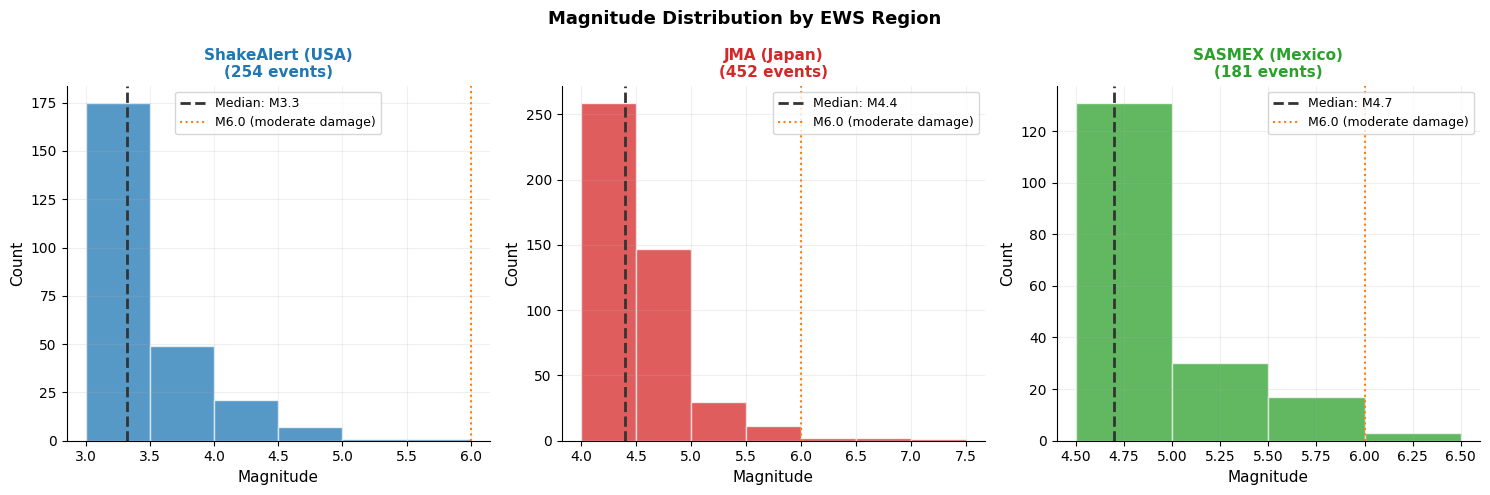

Region                      Events   Median M    Max M    M≥6 count
-----------------------------------------------------------------
ShakeAlert (USA)               254       3.32      5.7            0
JMA (Japan)                    452       4.40      7.4            5
SASMEX (Mexico)                181       4.70      6.5            3


In [5]:
import matplotlib.pyplot as plt

# Define colors
BLUE   = '#1f77b4'
RED    = '#d62728'
GREEN  = '#2ca02c'
DARK   = '#333333'
ORANGE = '#ff7f0e'
PURPLE = '#9467bd'

regions   = ['ShakeAlert (USA)', 'JMA (Japan)', 'SASMEX (Mexico)']
reg_cols  = [BLUE, RED, GREEN]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')

for ax, region, col in zip(axes, regions, reg_cols):
    d = df_all[df_all['region'] == region]
    mags = d['magnitude'].dropna()

    # Magnitude histogram
    ax.hist(mags, bins=np.arange(mags.min(), mags.max()+0.5, 0.5),
            color=col, alpha=0.75, edgecolor='white', lw=0.5)
    ax.axvline(mags.median(), color=DARK, lw=2, ls='--',
               label=f'Median: M{mags.median():.1f}')
    ax.axvline(6.0, color=ORANGE, lw=1.5, ls=':',
               label='M6.0 (moderate damage)')

    ax.set_xlabel('Magnitude', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{region}\n({len(d)} events)', fontsize=11, fontweight='bold', color=col)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Magnitude Distribution by EWS Region', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print(f"{'Region':<25} {'Events':>8} {'Median M':>10} {'Max M':>8} {'M≥6 count':>12}")
print('-' * 65)
for region in regions:
    d = df_all[df_all['region'] == region]
    mags = d['magnitude'].dropna()
    print(f"{region:<25} {len(d):>8} {mags.median():>10.2f} {mags.max():>8.1f} {(mags>=6.0).sum():>12}")

---
## Part 3 — ShakeAlert: Computing Warning Times

For each earthquake in the ShakeAlert region, we simulate how much warning time Los Angeles (34.05°N, 118.24°W) would receive, given the 2019 Ridgecrest-validated alert generation lag of ~10 seconds.

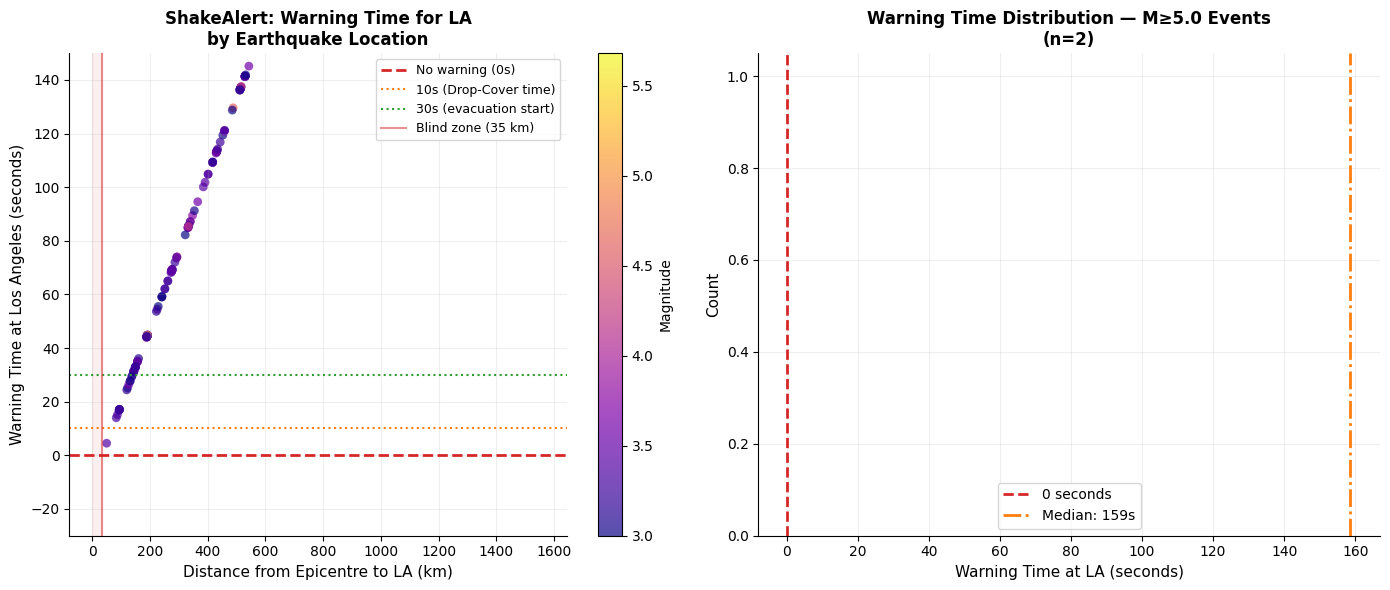

M≥5.0 events with >0s warning for LA: 2 / 2
Median warning time (M≥5): 158.6s
Blind zone: within 35 km of LA — 0 events had no warning


In [6]:
# Los Angeles coordinates
LA_LAT, LA_LON = 34.05, -118.24

def haversine_km(lat1, lon1, lat2, lon2):
    """Distance in km between two lat/lon points."""
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df_usa = df_usa.copy()
df_usa['dist_to_LA_km'] = df_usa.apply(
    lambda r: haversine_km(r['latitude'], r['longitude'], LA_LAT, LA_LON), axis=1
)

S_WAVE_SPEED = 3.5   # km/s
ALERT_LAG    = 10.0  # seconds (generation + dissemination)

df_usa['s_wave_LA_s']   = df_usa['dist_to_LA_km'] / S_WAVE_SPEED
df_usa['warning_time_s'] = df_usa['s_wave_LA_s'] - ALERT_LAG

# Plot warning time vs. distance and magnitude
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# Left: warning time vs. distance, coloured by magnitude
sc = ax1.scatter(df_usa['dist_to_LA_km'], df_usa['warning_time_s'],
                 c=df_usa['magnitude'], cmap='plasma',
                 s=40, alpha=0.7, edgecolors='none')
plt.colorbar(sc, ax=ax1, label='Magnitude')
ax1.axhline(0, color=RED, lw=2, ls='--', label='No warning (0s)')
ax1.axhline(10, color=ORANGE, lw=1.5, ls=':', label='10s (Drop-Cover time)')
ax1.axhline(30, color=GREEN, lw=1.5, ls=':', label='30s (evacuation start)')
ax1.axvline(ALERT_LAG * S_WAVE_SPEED, color=RED, lw=1.5, ls='-', alpha=0.5,
            label=f'Blind zone ({ALERT_LAG*S_WAVE_SPEED:.0f} km)')
ax1.fill_between([0, ALERT_LAG*S_WAVE_SPEED], [-30,-30], [200,200],
                  color=RED, alpha=0.07)
ax1.set_xlabel('Distance from Epicentre to LA (km)', fontsize=11)
ax1.set_ylabel('Warning Time at Los Angeles (seconds)', fontsize=11)
ax1.set_title('ShakeAlert: Warning Time for LA\nby Earthquake Location', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_ylim(-30, 150)
ax1.grid(True, alpha=0.2)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Right: warning time distribution for M≥5
sig = df_usa[df_usa['magnitude'] >= 5.0]
ax2.hist(sig['warning_time_s'], bins=20, color=PURPLE, alpha=0.75, edgecolor='white')
ax2.axvline(0, color=RED, lw=2, ls='--', label='0 seconds')
ax2.axvline(sig['warning_time_s'].median(), color=ORANGE, lw=2, ls='-.',
            label=f'Median: {sig["warning_time_s"].median():.0f}s')
ax2.set_xlabel('Warning Time at LA (seconds)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title(f'Warning Time Distribution — M≥5.0 Events\n(n={len(sig)})', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

useful = (df_usa['warning_time_s'] > 0) & (df_usa['magnitude'] >= 5.0)
print(f'M≥5.0 events with >0s warning for LA: {useful.sum()} / {(df_usa["magnitude"]>=5.0).sum()}')
print(f'Median warning time (M≥5): {sig["warning_time_s"].median():.1f}s')
print(f'Blind zone: within {ALERT_LAG * S_WAVE_SPEED:.0f} km of LA — {(df_usa["dist_to_LA_km"] < ALERT_LAG*S_WAVE_SPEED).sum()} events had no warning')

---
## Part 4 — SASMEX: Identifying Tsunamigenic Earthquakes

Not all earthquakes generate tsunamis. SASMEX uses GPS to detect ground displacement and assesses tsunamigenic potential based on magnitude AND depth. Deep earthquakes rarely generate tsunamis.

**Tsunami criteria (simplified):**
- Magnitude ≥ 7.0
- Depth ≤ 50 km (shallow crustal/interface event)
- Subduction interface location (Pacific coast)

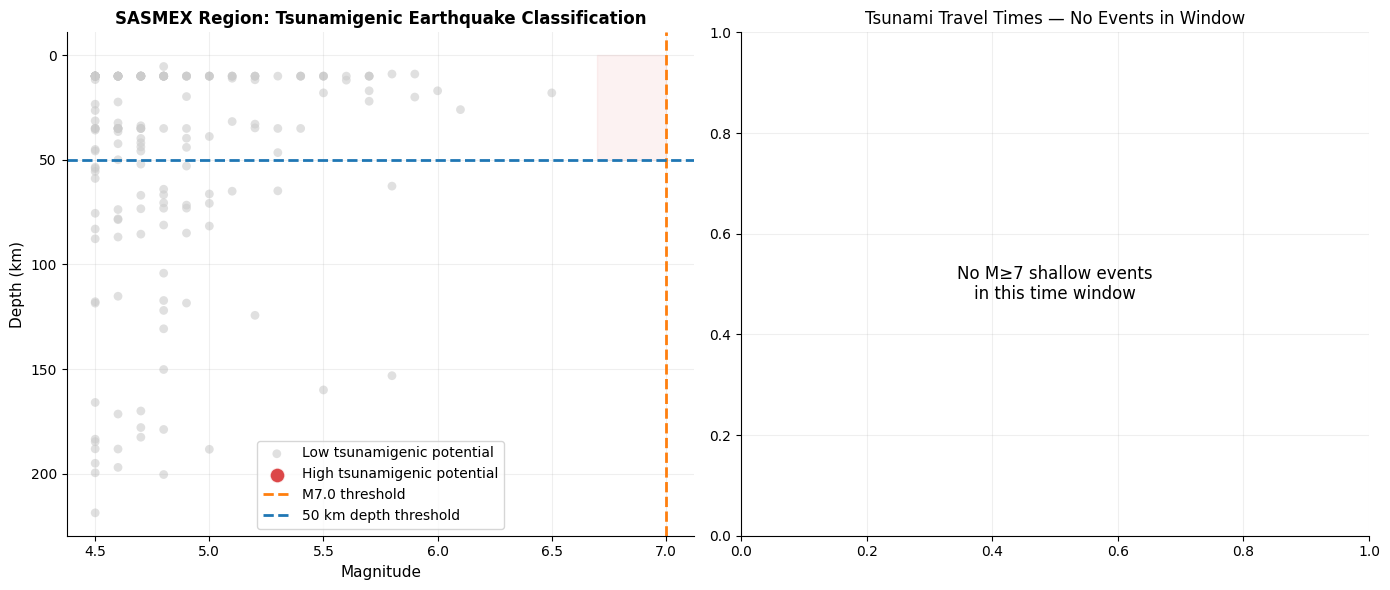

Total Mexico/Central America events: 181
Classified as tsunamigenic (M≥7.0, depth≤50km): 0


In [7]:
df_mexico = df_mexico.copy()

# Classify tsunamigenic potential
df_mexico['tsunamigenic'] = (
    (df_mexico['magnitude'] >= 7.0) &
    (df_mexico['depth_km']  <= 50)
)

# Warning time to Acapulco coast (16.86°N, -99.88°W)
ACAPULCO_LAT, ACAPULCO_LON = 16.86, -99.88
TSUNAMI_SPEED = 200  # km/h in shallow coastal waters (simplified)

df_mexico['dist_coast_km'] = df_mexico.apply(
    lambda r: haversine_km(r['latitude'], r['longitude'], ACAPULCO_LAT, ACAPULCO_LON), axis=1
)
df_mexico['tsunami_travel_min'] = (df_mexico['dist_coast_km'] / TSUNAMI_SPEED) * 60

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# Left: magnitude vs. depth, coloured by tsunamigenic potential
ax = axes[0]
non_tsun = df_mexico[~df_mexico['tsunamigenic']]
tsun     = df_mexico[ df_mexico['tsunamigenic']]

ax.scatter(non_tsun['magnitude'], non_tsun['depth_km'],
           c='#cccccc', s=40, alpha=0.6, label='Low tsunamigenic potential', edgecolors='none')
ax.scatter(tsun['magnitude'], tsun['depth_km'],
           c=RED, s=120, alpha=0.85, label='High tsunamigenic potential', edgecolors='white', lw=1.2)
ax.axvline(7.0,  color=ORANGE, lw=2, ls='--', label='M7.0 threshold')
ax.axhline(50.0, color=BLUE,   lw=2, ls='--', label='50 km depth threshold')
ax.fill_between([7.0, df_mexico['magnitude'].max()+0.2], [0, 0], [50, 50],
                 color=RED, alpha=0.06)
ax.set_xlabel('Magnitude', fontsize=11)
ax.set_ylabel('Depth (km)', fontsize=11)
ax.set_title('SASMEX Region: Tsunamigenic Earthquake Classification', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: tsunami travel time distribution
ax2 = axes[1]
if len(tsun) > 0:
    ax2.hist(tsun['tsunami_travel_min'], bins=12, color=BLUE, alpha=0.75, edgecolor='white')
    ax2.axvline(10, color=RED, lw=2, ls='--', label='10 min (critical threshold)')
    ax2.axvline(30, color=ORANGE, lw=1.5, ls=':', label='30 min')
    ax2.set_xlabel('Tsunami Travel Time to Acapulco Coast (minutes)', fontsize=11)
    ax2.set_ylabel('Count', fontsize=11)
    ax2.set_title(f'Tsunami Travel Times — Tsunamigenic Events\n(n={len(tsun)})',
                  fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
else:
    ax2.text(0.5, 0.5, 'No M≥7 shallow events\nin this time window',
             ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('Tsunami Travel Times — No Events in Window', fontsize=12)

ax2.grid(True, alpha=0.2)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Total Mexico/Central America events: {len(df_mexico)}')
print(f'Classified as tsunamigenic (M≥7.0, depth≤50km): {df_mexico["tsunamigenic"].sum()}')
if len(tsun) > 0:
    print(f'Median tsunami travel time to coast: {tsun["tsunami_travel_min"].median():.1f} minutes')
    print(f'Events with < 10 min travel time: {(tsun["tsunami_travel_min"] < 10).sum()}')

---
## Part 5 — Cross-Region Comparison: Lessons for EWS Design

A final comparison of all three regions side-by-side.

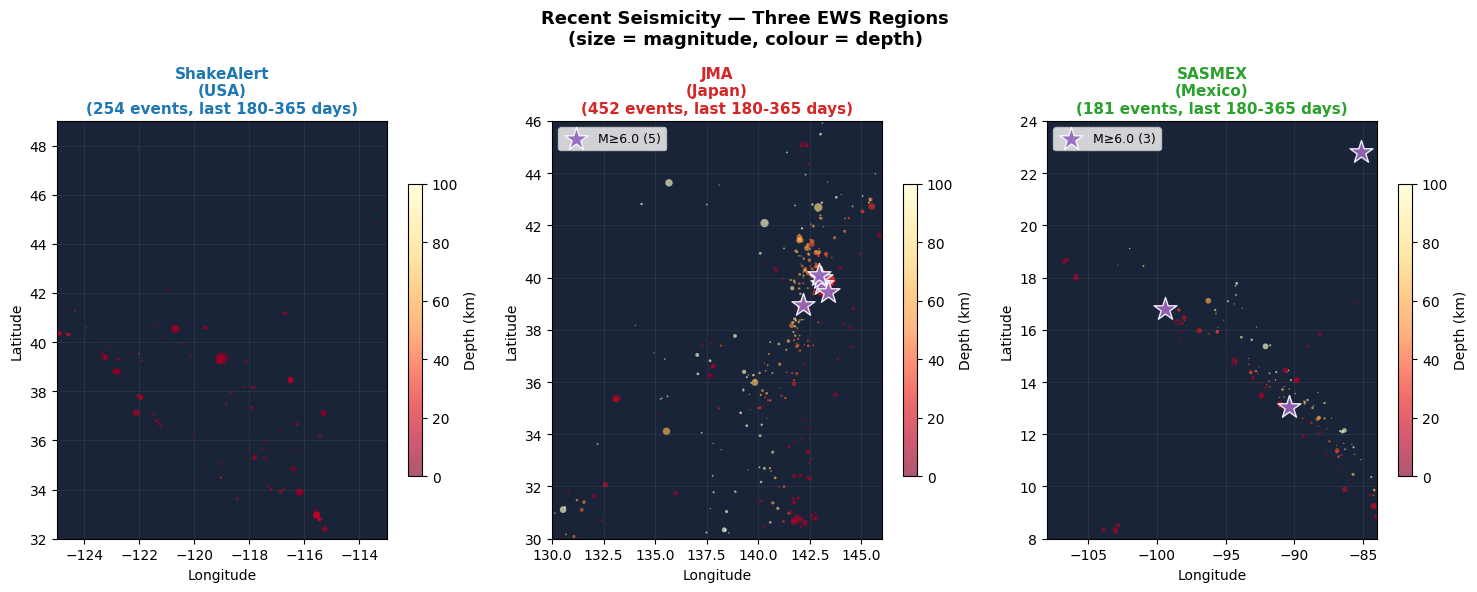

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), facecolor='white')

datasets  = [df_usa,    df_japan,   df_mexico]
reg_cols  = [BLUE,      RED,        GREEN]
titles    = ['ShakeAlert\n(USA)', 'JMA\n(Japan)', 'SASMEX\n(Mexico)']
xlims     = [(-125,-113), (130,146), (-108,-84)]
ylims     = [(32,49),    (30,46),   (8,24)]

for ax, df_r, col, title, xlim, ylim in zip(axes, datasets, reg_cols, titles, xlims, ylims):
    # Size scaled by magnitude, colour by depth
    mags   = df_r['magnitude'].fillna(5.0)
    depths = df_r['depth_km'].fillna(20)

    sc = ax.scatter(df_r['longitude'], df_r['latitude'],
                    s=((mags - mags.min() + 0.5)**2.5) * 4,
                    c=depths, cmap='YlOrRd_r',
                    alpha=0.65, edgecolors='none',
                    vmin=0, vmax=100)

    # Highlight M≥6
    big = df_r[df_r['magnitude'] >= 6.0]
    if len(big) > 0:
        ax.scatter(big['longitude'], big['latitude'],
                   s=300, c=PURPLE, marker='*',
                   alpha=0.9, edgecolors='white', lw=1, zorder=5,
                   label=f'M≥6.0 ({len(big)})')

    plt.colorbar(sc, ax=ax, label='Depth (km)', shrink=0.7)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_ylabel('Latitude', fontsize=10)
    ax.set_title(f'{title}\n({len(df_r)} events, last 180-365 days)',
                 fontsize=11, fontweight='bold', color=col)
    if len(big) > 0:
        ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.2, color='#666')
    ax.set_facecolor('#1a2438')

fig.suptitle('Recent Seismicity — Three EWS Regions\n(size = magnitude, colour = depth)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✏️ Reflection Questions

Double-click this cell to write your answers.

### Student Reflection

**Student name:** [Your name here]

**Question 1:** Looking at Part 3, how many M≥5 earthquakes near the ShakeAlert network would give Los Angeles less than 10 seconds of warning? What does this tell you about the limitations of EWS for local earthquakes?

> *[Your answer here]*

**Question 2:** In Part 4 (SASMEX), why do we use BOTH magnitude AND depth to classify tsunamigenic potential? What would happen if we used magnitude alone?

> *[Your answer here]*

**Question 3:** Comparing all three regions in Part 5, which region presents the greatest challenge for EWS design in terms of (a) frequency of events and (b) geographic distribution? What operational implications does this have?

> *[Your answer here]*

---
*DigiHaz Module 5 — Notebook 3 of 3 | github.com/Digihaz/early-warning-system-workshop*

**Data source:** USGS Earthquake Hazards Program — https://earthquake.usgs.gov/fdsnws/event/1/ (open data, freely available)

**Submission:** Save this notebook and upload to Moodle Module 5 assignment.